<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Hands-on Lab : Web Scraping**


Estimated time needed: **30 to 45** minutes


## Objectives


In this lab you will perform the following:


* Extract information from a given web site 
* Write the scraped data into a csv file.


## Extract information from the given web site
You will extract the data from the below web site: <br> 


In [3]:
#this url contains the data you need to scrape
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"

The data you need to scrape is the **name of the programming language** and **average annual salary**.<br> It is a good idea to open the url in your web broswer and study the contents of the web page before you start to scrape.


Import the required libraries


In [4]:
from bs4 import BeautifulSoup # this module helps in web scrapping.
import requests  # this module helps us to download a webpage

Download the webpage at the url


In [5]:
#your code goes here
data  = requests.get(url).text 

Create a soup object


In [6]:
#your code goes here
soup = BeautifulSoup(data,"html.parser")  # create a soup object using the variable 'data'

Scrape the `Language name` and `annual average salary`.


In [7]:
#your code goes here
import requests
from bs4 import BeautifulSoup

# Step 1: Define the URL
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"

# Step 2: Download the webpage content
response = requests.get(url)
html_data = response.text

# Step 3: Parse the HTML using BeautifulSoup
soup = BeautifulSoup(html_data, "html.parser")

# Step 4: Locate the table
table = soup.find("table")

# Step 5: Extract rows from the table
rows = table.find_all("tr")

# Step 6: Loop through each row and print language name and salary
print("Programming Languages and Average Annual Salaries:\n")
for row in rows[1:]:  # Skip the header row
    cols = row.find_all("td")
    language = cols[1].text.strip()
    salary = cols[3].text.strip()
    print(f"{language}: {salary}")

Programming Languages and Average Annual Salaries:

Python: $114,383
Java: $101,013
R: $92,037
Javascript: $110,981
Swift: $130,801
C++: $113,865
C#: $88,726
PHP: $84,727
SQL: $84,793
Go: $94,082


Save the scrapped data into a file named *popular-languages.csv*


In [10]:
# your code goes here
import csv

# Save data to CSV
with open("popular-languages.csv", mode="w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow(["Language", "Average Annual Salary"])  # Write header

    for row in rows[1:]:  # Skip the header row
        cols = row.find_all("td")
        language = cols[1].text.strip()
        salary = cols[3].text.strip()
        writer.writerow([language, salary])

/home/jupyterlab/conda/envs/python/lib/python3.7/site-packages/ipykernel_launcher.py:33: UserWarning: FixedFormatter should only be used together with FixedLocator


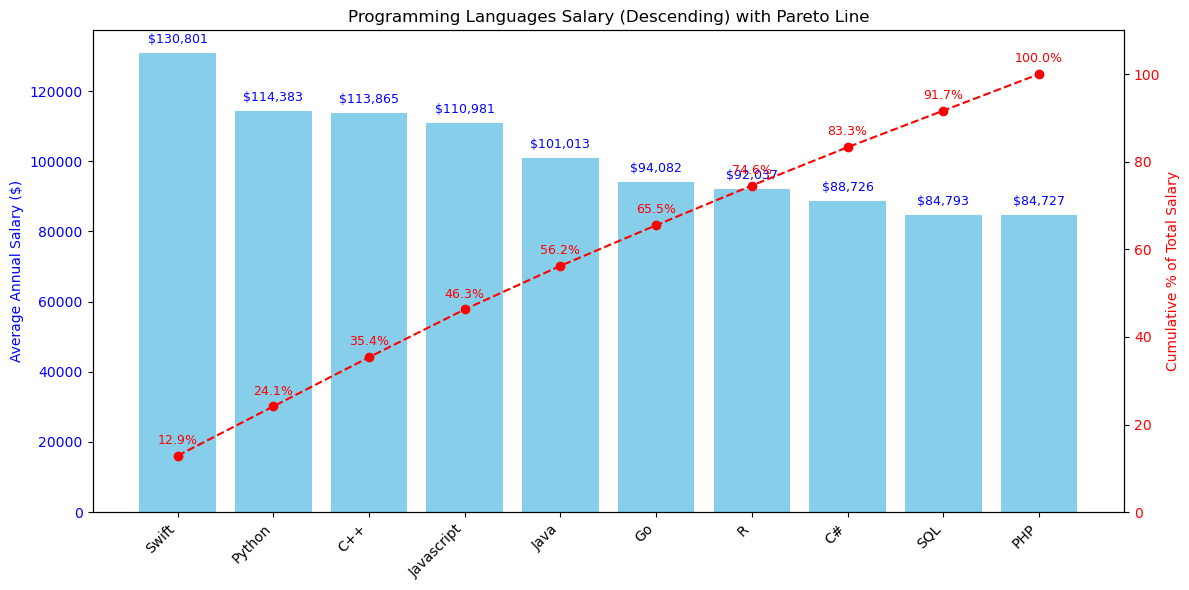

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Your scraped data
data = [
    ("Python", 114383),
    ("Java", 101013),
    ("R", 92037),
    ("Javascript", 110981),
    ("Swift", 130801),
    ("C++", 113865),
    ("C#", 88726),
    ("PHP", 84727),
    ("SQL", 84793),
    ("Go", 94082)
]

# Step 2: Create DataFrame and sort by salary descending
df = pd.DataFrame(data, columns=["Language", "Salary"])
df = df.sort_values(by="Salary", ascending=False)

# Step 3: Calculate cumulative percentage for Pareto chart
df["Cumulative %"] = df["Salary"].cumsum() / df["Salary"].sum() * 100

# Step 4: Plot bar chart with Pareto line
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart
bars = ax1.bar(df["Language"], df["Salary"], color="skyblue")
ax1.set_ylabel("Average Annual Salary ($)", color="blue")
ax1.set_title("Programming Languages Salary (Descending) with Pareto Line")
ax1.tick_params(axis='y', labelcolor="blue")
ax1.set_xticklabels(df["Language"], rotation=45, ha="right")

# Add salary labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height + 2000, f"${height:,}", 
             ha='center', va='bottom', fontsize=9, color='blue')

# Pareto line
ax2 = ax1.twinx()
pareto_line = ax2.plot(df["Language"], df["Cumulative %"], color="red", marker="o", linestyle="--")
ax2.set_ylabel("Cumulative % of Total Salary", color="red")
ax2.tick_params(axis='y', labelcolor="red")
ax2.set_ylim(0, 110)

# Add percentage labels on Pareto points
for i, pct in enumerate(df["Cumulative %"]):
    ax2.text(i, pct + 2, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9, color='red')

plt.tight_layout()
plt.show()

## Authors


Ramesh Sannareddy


### Other Contributors


Rav Ahuja


## Change Log


|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
|---|---|---|---|
| 2020-10-17  | 0.1  | Ramesh Sannareddy  |  Created initial version of the lab |


 Copyright &copy; 2020 IBM Corporation. This notebook and its source code are released under the terms of the [MIT License](https://cognitiveclass.ai/mit-license/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2022-01-01).
